In [ ]:
# Set Up
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

# Check device
device = torch.device('cuda' if torch.cuda.is_available()
                       else 'cpu')
print(f" PyTorch version: {torch.__version__}")
print(f" Device: {device}")
if device.type == 'cuda':
    print(f" GPU: {torch.cuda.get_device_name(0)}")
    print(f" Memory: "
          f"{torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
else:
    print(" No GPU found. Go to Runtime → Change runtime type → T4 GPU")
    print("   CPU will still work for today's exercises")

torch.manual_seed(42)
np.random.seed(42)
print("\n Ready. Let's learn PyTorch.")

 PyTorch version: 2.10.0+cu128
 Device: cuda
 GPU: Tesla T4
 Memory: 15.6 GB

 Ready. Let's learn PyTorch.


**PyTorch Tensors, Numpy Arrays on Steroids**

The analogy, a regular calculator vs a scientific calculator:

A numpy array is like a regular calculator, it does maths perfectly but has no memory of how it got to an answer.

A PyTorch tensor is like a scientific calculator that records every button you pressed. When you are done, you can press 'undo' and it tells you exactly how each number contributed to the final answer. That recording is called the computational graph, and 'undoing' it is backpropagation.

This is the entire magic of pytorch, automatic differentiation. You do the forward pass, pytorch records everything, then .backward() plays it all back in reverse to compute every gradient automatically.



In [ ]:
# CONCEPT 1: Tensors and Autogradients

print("PART 1: Tensors are just like NumPy arrays")
print("=" * 50)

# Creating tensors
t1 = torch.tensor([1.0, 2.0, 3.0])
t2 = torch.zeros(3, 4)
t3 = torch.randn(2, 3)      # standard normal
t4 = torch.ones(2, 2)

print(f"From list:     {t1}")
print(f"Zeros (3×4):\n{t2}")
print(f"Random (2×3):\n{t3}")
print(f"Shape:         {t3.shape}")
print(f"Dtype:         {t3.dtype}")
print(f"Device:        {t3.device}")

print("\n--- Tensor operations (same as NumPy) ---")
a = torch.tensor([1.0, 2.0, 3.0])
b = torch.tensor([4.0, 5.0, 6.0])
print(f"a + b     = {a + b}")
print(f"a × b     = {a * b}")
print(f"a @ b     = {torch.dot(a, b)}")  # dot product
print(f"a.mean()  = {a.mean():.4f}")
print(f"a.sum()   = {a.sum():.4f}")

# Convert between NumPy and PyTorch
np_array    = np.array([1.0, 2.0, 3.0])
torch_tensor = torch.from_numpy(np_array)
back_to_numpy = torch_tensor.numpy()
print(f"\nNumPy → Torch: {torch_tensor}")
print(f"Torch → NumPy: {back_to_numpy}")

PART 1: Tensors are just like NumPy arrays
From list:     tensor([1., 2., 3.])
Zeros (3×4):
tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])
Random (2×3):
tensor([[ 0.3367,  0.1288,  0.2345],
        [ 0.2303, -1.1229, -0.1863]])
Shape:         torch.Size([2, 3])
Dtype:         torch.float32
Device:        cpu

--- Tensor operations (same as NumPy) ---
a + b     = tensor([5., 7., 9.])
a × b     = tensor([ 4., 10., 18.])
a @ b     = 32.0
a.mean()  = 2.0000
a.sum()   = 6.0000

NumPy → Torch: tensor([1., 2., 3.], dtype=torch.float64)
Torch → NumPy: [1. 2. 3.]



PART 2: Autograd — This is WHY PyTorch exists

ANALOGY: PyTorch records every operation.
Then .backward() replays them in reverse.
That replay IS backpropagation.

w=2.0, x=3.0, b=1.0
y = w*x + b = 7.0
loss = (y-5)² = 4.0

Gradient dLoss/dw = 12.0
Gradient dLoss/db = 4.0

Let's verify by hand:
dLoss/dy = 2×(y-5) = 2×(7-5) = 4
dy/dw    = x = 3.0
dLoss/dw = dLoss/dy × dy/dw = 4 × 3.0 = 12.0

 PyTorch got the same answer as our manual calculation!
   This is exactly the chain rule.
   PyTorch just does it automatically for ALL weights.


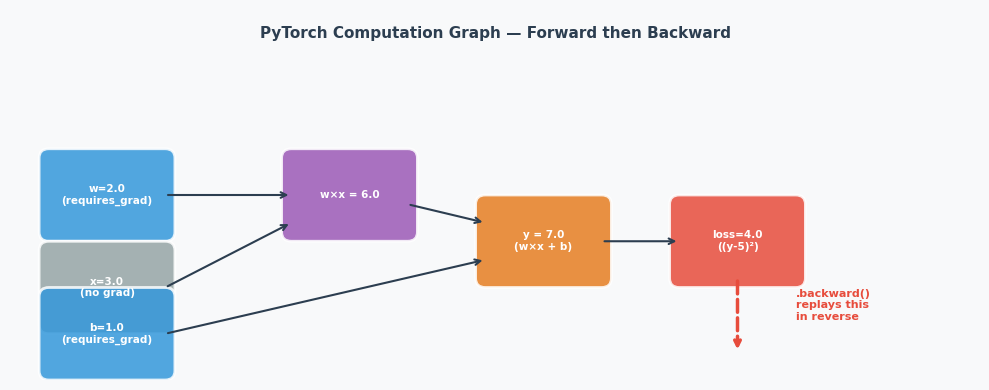

In [ ]:
# THE MAGIC: Autograd — automatic differentiation

import matplotlib.patches as mpatches # Moved this import here

print("\nPART 2: Autograd — This is WHY PyTorch exists")
print("=" * 50)
print()
print("ANALOGY: PyTorch records every operation.")
print("Then .backward() replays them in reverse.")
print("That replay IS backpropagation.")
print()

# requires_grad=True tells PyTorch: "track everything done to this tensor"
w = torch.tensor(2.0, requires_grad=True)
b = torch.tensor(1.0, requires_grad=True)
x = torch.tensor(3.0)   # input, no grad needed

# Forward pass: y = w*x + b
# (This is one linear neuron)
y    = w * x + b         # y = 2×3 + 1 = 7
loss = (y - 5.0) ** 2   # MSE loss: (7-5)² = 4

print(f"w={w.item()}, x={x.item()}, b={b.item()}")
print(f"y = w*x + b = {y.item()}")
print(f"loss = (y-5)² = {loss.item()}")
print()

# Backward pass: compute gradients
# PyTorch uses the chain rule automatically
loss.backward()

print(f"Gradient dLoss/dw = {w.grad.item()}")
print(f"Gradient dLoss/db = {b.grad.item()}")
print()
print("Let's verify by hand:")
print(f"dLoss/dy = 2×(y-5) = 2×(7-5) = {2*(7-5)}")
print(f"dy/dw    = x = {x.item()}")
print(f"dLoss/dw = dLoss/dy × dy/dw = "
      f"{2*(7-5)} × {x.item()} = {2*(7-5)*x.item()}")
print()
print(" PyTorch got the same answer as our manual calculation!")
print("   This is exactly the chain rule.")
print("   PyTorch just does it automatically for ALL weights.")

# Visualise the computation graph concept
fig, ax = plt.subplots(figsize=(10, 4))
ax.set_xlim(0, 10)
ax.set_ylim(0, 4)
ax.axis('off')
ax.set_facecolor('#F8F9FA')
fig.patch.set_facecolor('#F8F9FA')

nodes = [
    (1.0, 2.0, 'w=2.0\n(requires_grad)', '#3498DB'),
    (1.0, 1.0, 'x=3.0\n(no grad)', '#95A5A6'),
    (3.5, 2.0, 'w×x = 6.0', '#9B59B6'),
    (1.0, 0.5, 'b=1.0\n(requires_grad)', '#3498DB'),
    (5.5, 1.5, 'y = 7.0\n(w×x + b)', '#E67E22'),
    (7.5, 1.5, 'loss=4.0\n((y-5)²)', '#E74C3C'),
]

for x_pos, y_pos, label, color in nodes:
    rect = mpatches.FancyBboxPatch(
        (x_pos-0.6, y_pos-0.4), 1.2, 0.8,
        boxstyle="round,pad=0.1",
        facecolor=color, alpha=0.85,
        edgecolor='white', linewidth=2)
    ax.add_patch(rect)
    ax.text(x_pos, y_pos, label, ha='center',
            va='center', fontsize=7.5,
            color='white', fontweight='bold')

arrows = [(1.6,2.0,2.9,2.0),(1.6,1.0,2.9,1.7),
          (4.1,1.9,4.9,1.7),(1.6,0.5,4.9,1.3),
          (6.1,1.5,6.9,1.5)]
for x1,y1,x2,y2 in arrows:
    ax.annotate('', xy=(x2,y2), xytext=(x1,y1),
                arrowprops=dict(arrowstyle='->',
                                color='#2C3E50', lw=1.5))

ax.annotate('', xy=(7.5,0.3), xytext=(7.5,1.1),
            arrowprops=dict(arrowstyle='->',
                            color='#E74C3C', lw=2.5,
                            linestyle='dashed'))
ax.text(8.1, 0.65, '.backward()\nreplays this\nin reverse',
        fontsize=8, color='#E74C3C', fontweight='bold')

ax.text(5.0, 3.7,
        "PyTorch Computation Graph — Forward then Backward",
        ha='center', fontsize=11,
        fontweight='bold', color='#2C3E50')

plt.tight_layout()
plt.show()

**Building Networks with nn.Module**

The analogy, LEGO vs building from raw plastic:

Yesterday we built a neural network from raw plastic, manually creating every weight matrix, every gradient calculation, every update rule.

PyTorch's nn.Module is like LEGO. you snap together pre-built, tested, GPU-ready components. The pieces are the same (linear layers, activations, loss function), but assembly is fater and less error-prone.

And here is the key: the components do exactly what we built yesterday. nn.Linaer is W @ x + b, nn.ReLU is np.maximum(0,z). .backward() is entire backward pass.


In [ ]:
# Network - Rebuilt in pytorch

class NeuralNetworkPyTorch(nn.Module):
  # W1 = np.random.randn(...) -> nn.Linear(in, out)
  # relu(z) -> nn.ReLU()
  # sigmoid(z) -> nn.Sigmoid()
  # W @ x + b -> linear_layer(x)
  # backward() manual -> loss.backward() auto
  # W -= lr * grad -> optimizer.step()

  def __init__(self, input_dim, hidden1, hidden2,
                 output_dim, dropout_rate=0.3):
        super().__init__()

        # nn.Linear(in_features, out_features)
        # = W matrix of shape (in, out) + bias vector
        self.network = nn.Sequential(
            # Layer 1
            nn.Linear(input_dim, hidden1),
            nn.BatchNorm1d(hidden1),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            # Layer 2
            nn.Linear(hidden1, hidden2),
            nn.BatchNorm1d(hidden2),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            # Output layer
            nn.Linear(hidden2, output_dim),
            nn.Sigmoid()
        )

        # He initialisation
        self._initialise_weights()

  def _initialise_weights(self):
      for layer in self.network:
          if isinstance(layer, nn.Linear):
              # He init: std = sqrt(2 / fan_in)
              nn.init.kaiming_normal_(
                  layer.weight, mode='fan_in',
                  nonlinearity='relu')
              nn.init.zeros_(layer.bias)

  def forward(self, x):
      # nn.Sequential handles the chain automatically
      # This replaces your entire manual forward() method
      return self.network(x)


# Build the model
model = NeuralNetworkPyTorch(
    input_dim=2,
    hidden1=64,
    hidden2=32,
    output_dim=1,
    dropout_rate=0.3
).to(device)

#Inspect the Model
print("MODEL ARCHITECTURE:")
print("=" * 45)
print(model)
print()

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters()
                    if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable:,}")
print()
print("Each parameter = one number the network learns.")
print("More parameters = more capacity = higher risk of overfitting.")

MODEL ARCHITECTURE:
NeuralNetworkPyTorch(
  (network): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=32, out_features=1, bias=True)
    (9): Sigmoid()
  )
)

Total parameters:     2,497
Trainable parameters: 2,497

Each parameter = one number the network learns.
More parameters = more capacity = higher risk of overfitting.


**Batch Normalization**

The analogy, standardising exam scores across schools:

Imagine comparing students from two schools. School A gives hard exams (scores 20-40). School B gives easy exams (scores 80-100). If you compare raw scores, School B looks better, but it's unfair.

The fix: normalize eac school's scores to ave the same mean and spread. Now you are comparing apples to apples.

Batch Normalization does this for each layer's activations. After each layer's output, it normalizes the values to have mean=0 and std=1, then lets the network learn the best mean and std through two trainable parameters(gamma and beta).

Why It changes everything?

Problem without batchNorm:
-As data flows through layers, its distribution shifts.
- layer 3 sees a very different distribution than Layer 1.
- This makes training slow and unstable.
- Called Internal covariate shift

Solution: BatchNorm normalizes within each mini-batch:

- Step 1: Compute batch mean and variance. μ_batch = mean of activations in this mini-batch. σ²_batch = variance of activations in this mini-batch

- Step 2: Normalize. x_norm = (x - μ_batch) / sqrt(σ²_batch + ε). (ε = tiny number to prevent division by zero).

- Step 3: Scale and shift (learnable). output = γ × x_norm + β. γ (gamma) and β (beta) are learned by the network. This lets the network UNDO normalization if needed.

**Benefits**
- Trains Faster
- Less sensistive to weight initialization
- Acts a mild regularization
- Reduces vanishing gradient problem

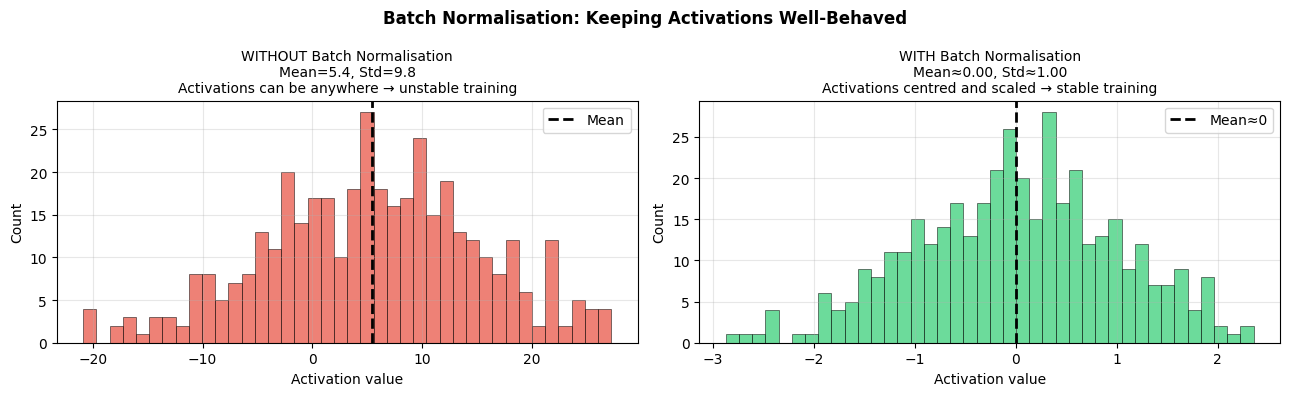

In [ ]:
# Demonstrate BatchNorm effect
np.random.seed(42)
torch.manual_seed(42)

# Simulate activations WITHOUT BatchNorm (distribution drifts)
activations_raw = torch.randn(100, 4) * 10 + 5
# With BatchNorm
bn_layer = nn.BatchNorm1d(4)
activations_normed = bn_layer(activations_raw)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(activations_raw.detach().numpy().ravel(),
             bins=40, color='#E74C3C',
             alpha=0.7, edgecolor='black',
             linewidth=0.5)
axes[0].set_title(
    "WITHOUT Batch Normalisation\n"
    f"Mean={activations_raw.mean():.1f}, "
    f"Std={activations_raw.std():.1f}\n"
    "Activations can be anywhere → unstable training",
    fontsize=10)
axes[0].set_xlabel("Activation value")
axes[0].set_ylabel("Count")
axes[0].axvline(activations_raw.mean().item(),
                color='black', linestyle='--',
                linewidth=2, label='Mean')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].hist(
    activations_normed.detach().numpy().ravel(),
    bins=40, color='#2ECC71',
    alpha=0.7, edgecolor='black',
    linewidth=0.5)
axes[1].set_title(
    "WITH Batch Normalisation\n"
    f"Mean≈{activations_normed.mean().item():.2f}, "
    f"Std≈{activations_normed.std().item():.2f}\n"
    "Activations centred and scaled → stable training",
    fontsize=10)
axes[1].set_xlabel("Activation value")
axes[1].set_ylabel("Count")
axes[1].axvline(
    activations_normed.mean().item(),
    color='black', linestyle='--',
    linewidth=2, label='Mean≈0')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle(
    "Batch Normalisation: Keeping Activations Well-Behaved",
    fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

**Dropout, Teaching the network to be robust**

The analogy: studying with a random group:

Imagine studying for an exam in an group of 10 people. If you always study with the same 10 people, you develop shortcuts, you rely on certain people to remeber certain things.

Now imagine every study session, 3 random people are absent. You can't rely on anyone specific, you have to actually learn everything yourself.

Dropout does exactly this to neurons. During training, it randomly switches off a fraction of neurons at each step. the remaining neurons can't rely on their neighbors, they must each learn robust, independent features.

At test time, all neurons are switched back on, but their outputs are scaled to maintain the same expected magnitude.



DROPOUT — Random Neuron Silencing

Original activations: [2. 2. 2. 2. 2. 2. 2. 2. 2. 2.]

During TRAINING (p=0.5):
  [4. 4. 4. 4. 0. 4. 0. 0. 4. 4.]
  Note: zeros = dropped neurons
  Remaining values scaled by 1/(1-p)=2 to maintain expected value

During EVALUATION (p=0.5):
  [2. 2. 2. 2. 2. 2. 2. 2. 2. 2.]
  All neurons active, no scaling needed

KEY INSIGHT:
ALWAYS call model.train() before training loop
ALWAYS call model.eval()  before validation/test
Forgetting this is a VERY common bug!


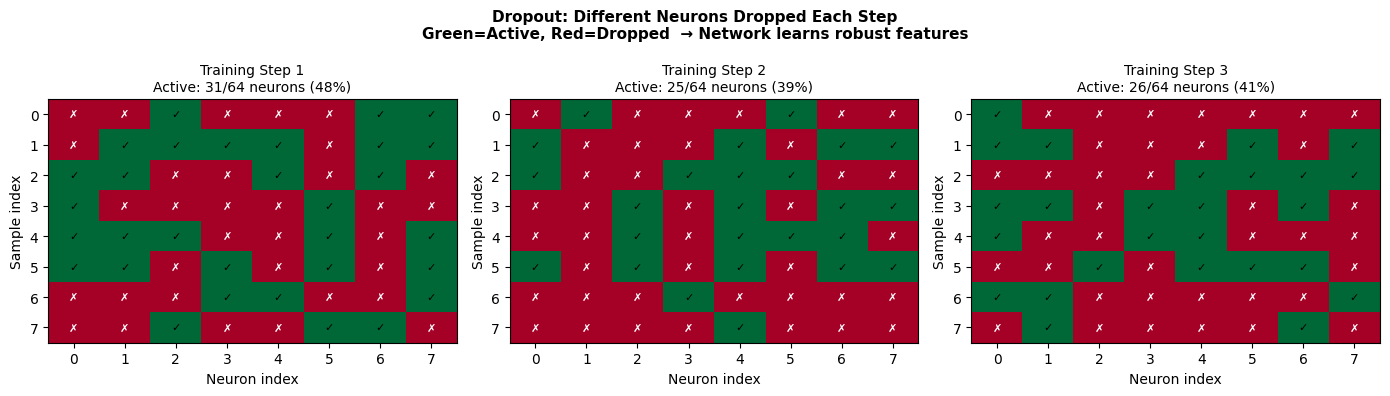

In [ ]:
# ══════════════════════════════════════════════════════
# DROPOUT — Visualised and understood
# ══════════════════════════════════════════════════════

print("DROPOUT — Random Neuron Silencing")
print("=" * 50)
print()

# Show what dropout does to activations
torch.manual_seed(42)
sample_activations = torch.ones(1, 10) * 2.0
print(f"Original activations: {sample_activations.numpy().ravel()}")

dropout_layer = nn.Dropout(p=0.5)  # 50% dropout

dropout_layer.train()  # Training mode: dropout is ACTIVE
out_train = dropout_layer(sample_activations)
print(f"\nDuring TRAINING (p=0.5):")
print(f"  {out_train.detach().numpy().ravel()}")
print(f"  Note: zeros = dropped neurons")
print(f"  Remaining values scaled by 1/(1-p)=2 "
      f"to maintain expected value")

dropout_layer.eval()   # Eval mode: dropout is DISABLED
out_eval = dropout_layer(sample_activations)
print(f"\nDuring EVALUATION (p=0.5):")
print(f"  {out_eval.detach().numpy().ravel()}")
print(f"  All neurons active, no scaling needed")

print()
print("KEY INSIGHT:")
print("ALWAYS call model.train() before training loop")
print("ALWAYS call model.eval()  before validation/test")
print("Forgetting this is a VERY common bug!")

# Visualise dropout patterns
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
dropout_layer.train()

for i, ax in enumerate(axes):
    torch.manual_seed(i * 10)
    acts = torch.ones(8, 8)
    dropped = dropout_layer(acts).detach().numpy()
    im = ax.imshow(
        (dropped > 0).astype(float),
        cmap='RdYlGn',
        vmin=0, vmax=1,
        aspect='auto')
    ax.set_title(
        f"Training Step {i+1}\n"
        f"Active: {(dropped>0).sum()}/64 neurons "
        f"({(dropped>0).mean():.0%})",
        fontsize=10)
    ax.set_xlabel("Neuron index")
    ax.set_ylabel("Sample index")
    for r in range(8):
        for c in range(8):
            color = 'white' if dropped[r,c] == 0 else 'black'
            ax.text(c, r,
                    '✓' if dropped[r,c] > 0 else '✗',
                    ha='center', va='center',
                    fontsize=8, color=color)

plt.suptitle(
    "Dropout: Different Neurons Dropped Each Step\n"
    "Green=Active, Red=Dropped  "
    "→ Network learns robust features",
    fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

**The complete PyTorch Training loop**

The analogy, a factory production line:

A professional training loop is like a well-designed factory:

- DataLoader: the conveyor belt that feed data in batches
- Forward pass: the assembly step
- Loss calculation: the quality check
- Backward pass: figurin out what went wrong
- Optimizer step: adjusting the machines
- Validation Loop: external quality audit every shift.

In [ ]:
def prepare_data_loaders(X_train, y_train,
                          X_val, y_val,
                          batch_size=32):
  # Convert numpy arrays to pytorch dataloaders.
  # data loader handles:
  # - Batching (splitting into mini-batches)
  # - Shuffling (different order each epoch)
  # - Moving to devic (CPU/GPU)

  # Convert to tensors
  X_tr_t=torch.FloatTensor(X_train)
  y_tr_t=torch.FloatTensor(y_train).unsqueeze(1)
  X_va_t=torch.FloatTensor(X_val)
  y_va_t=torch.FloatTensor(y_val).unsqueeze(1)

  # TensorDataset pairs X with y
  train_dataset=TensorDataset(X_tr_t, y_tr_t)
  val_dataset=TensorDataset(X_va_t, y_va_t)

  # DataLoader handles batching and shuffling
  train_loader=DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True) #Shuffle every epoch, # Drop incomplete last batch
  val_loader=DataLoader(val_dataset, batch_size, shuffle=False)

  return train_loader, val_loader

def train_one_epoch(model, loader, criterion, optimizer, device):
  # run one complete pass through training data
  # returns average loss and accuracy for this epoch

  # Crtical ! model.train() enables Dropout + BatchNorm
  model.train()

  total_loss=0
  total_correct=0
  total_samples=0

  for X_batch, y_batch in loader:
    # move data to GPU if available
    X_batch=X_batch.to(device)
    y_batch=y_batch.to(device)

    # Step 1: Zero gradients
    # pyTorch accumulates gradients by default
    # must clear them befpre each batch
    # forgetting this=gradients from previous batch contaminate current batch
    optimizer.zero_grad()

    #Step 2: Forward pass
    y_pred = model(X_batch)

    # step 3: Compute Loss
    loss = criterion(y_pred, y_batch)

    # step 4: backward pass
    # compute gradients for all parameters
    # Pytorch's autograd handles chain rule automatiocally
    loss.backward()

    # Step 5: Gradient Clipping
    # prevents exploding gradients
    # clips gradient norm to max value of 1.0
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

    # Step 6: Update weights
    # uses computed gradients to update W and b
    optimizer.step()

    #Track metrics
    total_loss    += loss.item() * len(X_batch)
    preds          = (y_pred >= 0.5).float()
    total_correct += (preds == y_batch).sum().item()
    total_samples += len(X_batch)

  avg_loss=total_loss/total_samples
  avg_acc=total_correct/total_samples

  return avg_loss, avg_acc

def evaluate_model(model, loader, criterion, device):
  #evaluate on validation or test data.
  # No gradient computation, we are not training

  #critical ! model.eval() disables Dropout + fixes BatchNorm
  model.eval()

  total_loss=0
  total_correct=0
  total_samples=0

  # torch.no_grad() tell putorch: dont build computation graph
  # makes evaluation faster and uses less memory

  with torch.no_grad():
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        y_pred = model(X_batch)
        loss   = criterion(y_pred, y_batch)

        total_loss    += loss.item() * len(X_batch)
        preds          = (y_pred >= 0.5).float()
        total_correct += (preds == y_batch).sum().item()
        total_samples += len(X_batch)

  return total_loss/total_samples, total_correct/total_samples


def full_training_loop(model, train_loader, val_loader, n_epochs=100, learning_rate=0.001, patience=15, device='cpu'):
  # complete training with:
  # Adam optimizer(adaptive learning rate)
  # Learning rate scheduler(reduce when stuck)
  # Early stopping (stop when validation stops improving)
  # full history tracking

  #optimixer: adam
  # adam= momentum + adaptive learnin rates
  # almost always better choice than plain SGD
  # lr=0.001 is the standard starting point
  optimizer = optim.Adam(
        model.parameters(),
        lr=learning_rate,
        weight_decay=1e-4) # L2 reguralization buit in

  #Loss Function
  criterion = nn.BCELoss() # binary cross entropy

  # scheduler: reduve LR on plateau
  #if val doesn't improve for 'patience' epochs,
  # multiply LR by 'factor' (make it smaller)

  scheduler=optim.lr_scheduler.ReduceLROnPlateau(
      optimizer,
      mode='min', # minimize validation loss
      factor=0.5, # Halve the learning rate
      patience=10 # wait 10 epochs before reducing
      )

  #early stopping
  # stop training if val loss does not improve
  # prevents wasting time and overfitting
  best_val_loss=float('inf')
  best_weights    = None
  patience_counter = 0

  history = {
        'train_loss': [], 'val_loss': [],
        'train_acc':  [], 'val_acc':  [],
        'lr':         []
    }

  print(f"{'Epoch':>6} {'Train Loss':>12} {'Train Acc':>11} "
          f"{'Val Loss':>10} {'Val Acc':>10} {'LR':>10}")
  print("-" * 62)

  for epoch in range(1, n_epochs + 1):
        # Train
        tr_loss, tr_acc = train_one_epoch(
            model, train_loader, criterion,
            optimizer, device)

        # Validate
        va_loss, va_acc = evaluate_model(
            model, val_loader, criterion, device)

        # Update scheduler
        scheduler.step(va_loss)

        # Track history
        history['train_loss'].append(tr_loss)
        history['val_loss'].append(va_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(va_acc)
        history['lr'].append(
            optimizer.param_groups[0]['lr'])

        # Print progress every 10 epochs
        if epoch % 10 == 0 or epoch == 1:
            current_lr = optimizer.param_groups[0]['lr']
            print(f"{epoch:>6} {tr_loss:>12.4f} "
                  f"{tr_acc:>11.4f} {va_loss:>10.4f} "
                  f"{va_acc:>10.4f} {current_lr:>10.6f}")

        # ── EARLY STOPPING CHECK ──
        if va_loss < best_val_loss:
            best_val_loss = va_loss
            # Save best weights
            best_weights    = {
                k: v.clone()
                for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"\n Early stopping at epoch {epoch}")
                print(f"   Best val loss: {best_val_loss:.4f}")
                break

  # Restore best weights
  if best_weights:
      model.load_state_dict(best_weights)
      print(f"\n Restored best model weights")

  return history

In [ ]:
# TRAIN ON REAL DATA — Moon shapes (non-linear problem)
# Data preparation
X_moon, y_moon = make_moons(
    n_samples=1000, noise=0.25, random_state=42)
X_temp, X_te, y_temp, y_te = train_test_split(
    X_moon, y_moon, test_size=0.15,
    random_state=42, stratify=y_moon)
X_tr, X_va, y_tr, y_va = train_test_split(
    X_temp, y_temp, test_size=0.15,
    random_state=42, stratify=y_temp)

scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)
X_va_s = scaler.transform(X_va)
X_te_s = scaler.transform(X_te)

print(f"Train:      {X_tr_s.shape[0]} samples")
print(f"Validation: {X_va_s.shape[0]} samples")
print(f"Test:       {X_te_s.shape[0]} samples")

# Prepare data loaders
train_loader, val_loader = prepare_data_loaders(
    X_tr_s, y_tr.astype(np.float32),
    X_va_s, y_va.astype(np.float32),
    batch_size=32)

# Build model
torch.manual_seed(42)
model = NeuralNetworkPyTorch(
    input_dim=2, hidden1=64,
    hidden2=32, output_dim=1,
    dropout_rate=0.2
).to(device)

print(f"\n{'='*45}")
print("TRAINING BEGINS")
print(f"{'='*45}\n")

# Train
history = full_training_loop(
    model, train_loader, val_loader,
    n_epochs=200, learning_rate=0.001,
    patience=20, device=device)

# Final test evaluation
test_loader = DataLoader(
    TensorDataset(
        torch.FloatTensor(X_te_s),
        torch.FloatTensor(y_te.astype(np.float32)).unsqueeze(1)),
    batch_size=64, shuffle=False)

criterion = nn.BCELoss()
test_loss, test_acc = evaluate_model(
    model, test_loader, criterion, device)

print(f"\n{'='*45}")
print(f"FINAL TEST RESULTS")
print(f"{'='*45}")
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Train:      722 samples
Validation: 128 samples
Test:       150 samples

TRAINING BEGINS

 Epoch   Train Loss   Train Acc   Val Loss    Val Acc         LR
--------------------------------------------------------------
     1       0.7031      0.6207     0.4595     0.7578   0.001000
    10       0.3039      0.8849     0.2166     0.9219   0.001000
    20       0.2607      0.9062     0.1614     0.9688   0.001000
    30       0.2540      0.8991     0.1385     0.9766   0.001000
    40       0.2312      0.9091     0.1222     0.9766   0.001000
    50       0.2491      0.8991     0.1150     0.9766   0.001000
    60       0.2417      0.8977     0.1151     0.9766   0.001000
    70       0.2351      0.9006     0.1084     0.9766   0.001000
    80       0.2244      0.9034     0.1074     0.9766   0.001000
    90       0.2089      0.9162     0.1002     0.9766   0.001000
   100       0.2262      0.9048     0.1051     0.9766   0.001000
   110       0.2334      0.9190     0.1054     0.9688   0.000500

 

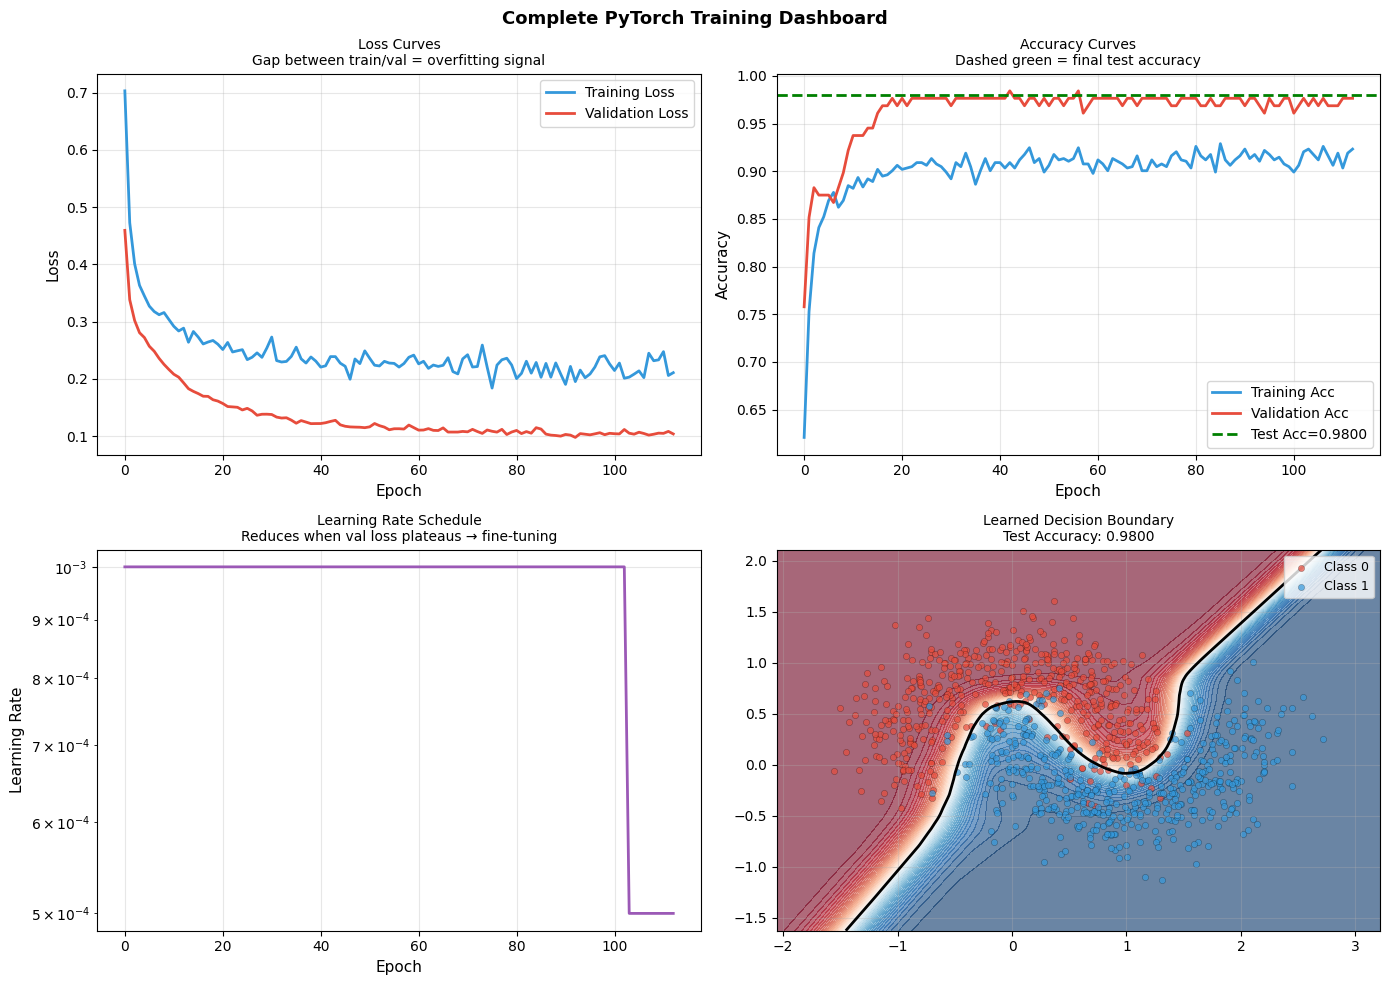

In [ ]:
# VISUALISE TRAINING — The complete picture

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Loss curves
axes[0,0].plot(history['train_loss'],
               color='#3498DB', linewidth=2,
               label='Training Loss')
axes[0,0].plot(history['val_loss'],
               color='#E74C3C', linewidth=2,
               label='Validation Loss')
axes[0,0].set_xlabel("Epoch", fontsize=11)
axes[0,0].set_ylabel("Loss", fontsize=11)
axes[0,0].set_title(
    "Loss Curves\n"
    "Gap between train/val = overfitting signal",
    fontsize=10)
axes[0,0].legend(fontsize=10)
axes[0,0].grid(alpha=0.3)

# 2. Accuracy curves
axes[0,1].plot(history['train_acc'],
               color='#3498DB', linewidth=2,
               label='Training Acc')
axes[0,1].plot(history['val_acc'],
               color='#E74C3C', linewidth=2,
               label='Validation Acc')
axes[0,1].axhline(test_acc, color='green',
                   linestyle='--', linewidth=2,
                   label=f'Test Acc={test_acc:.4f}')
axes[0,1].set_xlabel("Epoch", fontsize=11)
axes[0,1].set_ylabel("Accuracy", fontsize=11)
axes[0,1].set_title(
    "Accuracy Curves\n"
    "Dashed green = final test accuracy",
    fontsize=10)
axes[0,1].legend(fontsize=10)
axes[0,1].grid(alpha=0.3)

# 3. Learning rate schedule
axes[1,0].plot(history['lr'],
               color='#9B59B6', linewidth=2)
axes[1,0].set_xlabel("Epoch", fontsize=11)
axes[1,0].set_ylabel("Learning Rate", fontsize=11)
axes[1,0].set_title(
    "Learning Rate Schedule\n"
    "Reduces when val loss plateaus → fine-tuning",
    fontsize=10)
axes[1,0].grid(alpha=0.3)
axes[1,0].set_yscale('log')

# 4. Decision boundary
model.eval()
x_min = X_moon[:,0].min()-0.5
x_max = X_moon[:,0].max()+0.5
y_min = X_moon[:,1].min()-0.5
y_max = X_moon[:,1].max()+0.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200))
grid_np  = scaler.transform(
    np.c_[xx.ravel(), yy.ravel()])
grid_t   = torch.FloatTensor(grid_np).to(device)

with torch.no_grad():
    Z = model(grid_t).cpu().numpy().reshape(xx.shape)

axes[1,1].contourf(xx, yy, Z,
                    levels=50, cmap='RdBu', alpha=0.6)
axes[1,1].contour(xx, yy, Z,
                   levels=[0.5], colors='black',
                   linewidths=2)
axes[1,1].scatter(X_moon[y_moon==0,0],
                   X_moon[y_moon==0,1],
                   c='#E74C3C', s=20,
                   edgecolors='k', linewidth=0.2,
                   alpha=0.7, label='Class 0')
axes[1,1].scatter(X_moon[y_moon==1,0],
                   X_moon[y_moon==1,1],
                   c='#3498DB', s=20,
                   edgecolors='k', linewidth=0.2,
                   alpha=0.7, label='Class 1')
axes[1,1].set_title(
    f"Learned Decision Boundary\n"
    f"Test Accuracy: {test_acc:.4f}",
    fontsize=10)
axes[1,1].legend(fontsize=9)
axes[1,1].grid(alpha=0.3)

plt.suptitle(
    "Complete PyTorch Training Dashboard",
    fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**The PyTorch mental model **
```
When I call model(X_batch):
  → data flows through each nn.Linear (W@x + b)
  → through BatchNorm (normalise activations)
  → through ReLU (non-linearity)
  → through Dropout (randomly zero some neurons)
  → PyTorch builds a computation graph the whole time

When I call loss.backward():
  → PyTorch replays the computation graph in reverse
  → applies chain rule at every step automatically
  → stores gradient in each parameter's .grad attribute

When I call optimizer.step():
  → reads each parameter's .grad
  → applies Adam update rule
  → updates the weight value
  → the model is now slightly better